# Modelar XOR conectando perceptrones

En este cuaderno se muestra que la función XOR no se puede representar con un solo perceptrón, y se construye conectando varias neuronas básicas (compuertas AND, OR y NOT), cada una con sus pesos específicos. Al final se verifica que la red reproduce la tabla de verdad y se visualizan sus regiones de decisión.

## El problema XOR

La función XOR (o exclusivo) sobre dos entradas binarias vale $1$ cuando exactamente una de las entradas es $1$:

| $x_1$ | $x_2$ | XOR |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Los puntos donde XOR $=1$ son $(0,1)$ y $(1,0)$, que quedan en esquinas opuestas del cuadrado; los puntos donde XOR $=0$ son $(0,0)$ y $(1,1)$, en la otra diagonal. No existe ninguna recta que deje una diagonal a un lado y la otra al otro, así que XOR **no es linealmente separable** y un solo perceptrón no puede modelarla.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

entradas = [(0, 0), (0, 1), (1, 0), (1, 1)]
xor_val  = [0, 1, 1, 0]

# Un solo perceptrón sobre XOR: nunca llega a 0 errores
Xa = np.array([[1, a, b] for a, b in entradas])   # con sesgo x0 = 1
y  = np.where(np.array(xor_val) == 1, 1, -1)

w = np.zeros(3); errores = []
for _ in range(2000):
    pred = np.sign(Xa @ w); pred[pred == 0] = -1
    mal = np.where(pred != y)[0]
    errores.append(len(mal))
    if len(mal) == 0:
        break
    w = w + y[mal[0]] * Xa[mal[0]]

print("mínimo de errores alcanzado por un solo perceptrón:", min(errores))
print("(un 0 significaría que separa; nunca baja de 1)")

mínimo de errores alcanzado por un solo perceptrón: 1
(un 0 significaría que separa; nunca baja de 1)


Como se esperaba, un único perceptrón se queda siempre con al menos un punto mal clasificado: confirma que hace falta combinar varias neuronas.

## Neuronas básicas

Una neurona tipo perceptrón calcula una suma ponderada de sus entradas más un sesgo y aplica un umbral:

$$\text{salida} = \begin{cases} 1 & \text{si } w\cdot x + b > 0 \\ 0 & \text{en otro caso.}\end{cases}$$

Con pesos adecuados, una sola neurona reproduce las compuertas AND, OR y NOT (todas ellas sí son linealmente separables).

In [2]:
def neurona(x, w, b):
    return 1 if np.dot(w, x) + b > 0 else 0

# pesos específicos de cada compuerta
def AND(a, b): return neurona([a, b], w=[1, 1], b=-1.5)
def OR(a, b):  return neurona([a, b], w=[1, 1], b=-0.5)
def NOT(a):    return neurona([a],    w=[-1],   b=0.5)

print("AND:", [AND(a, b) for a, b in entradas], " (1 solo en (1,1))")
print("OR :", [OR(a, b)  for a, b in entradas], " (0 solo en (0,0))")
print("NOT:", [NOT(a) for a in [0, 1]], " (invierte la entrada)")

AND: [0, 0, 0, 1]  (1 solo en (1,1))
OR : [0, 1, 1, 1]  (0 solo en (0,0))
NOT: [1, 0]  (invierte la entrada)


Los pesos de cada compuerta se entienden mirando el umbral:

- **AND** con $b=-1.5$: la suma $x_1+x_2$ solo supera $1.5$ cuando ambas entradas valen $1$.
- **OR** con $b=-0.5$: la suma supera $0.5$ en cuanto alguna entrada vale $1$.
- **NOT** con $w=-1,\ b=0.5$: da $1$ cuando la entrada es $0$ y $0$ cuando es $1$.

## XOR conectando neuronas

XOR se puede escribir combinando esas compuertas. Una forma es

$$\text{XOR}(x_1,x_2) = \text{OR}(x_1,x_2)\ \text{Y}\ \text{NO}\,\big(\text{AND}(x_1,x_2)\big),$$

es decir: "al menos una entrada encendida, pero no las dos". Esto se arma con dos capas:

- **Capa oculta** (dos neuronas sobre las entradas):
  - $h_1 = \text{OR}(x_1,x_2)$ con pesos $[1,1]$ y sesgo $-0.5$.
  - $h_2 = \text{AND}(x_1,x_2)$ con pesos $[1,1]$ y sesgo $-1.5$.
- **Capa de salida** (una neurona sobre $h_1,h_2$) que calcula $h_1$ Y NO $h_2$:
  - $y = $ neurona con pesos $[\,1,\,-1\,]$ y sesgo $-0.5$.

Los pesos de la salida $[1,-1]$ con sesgo $-0.5$ dan $1$ solo cuando $h_1=1$ y $h_2=0$, que es justo el caso de "una sí, la otra no".

In [3]:
def xor_red(a, b):
    # capa oculta
    h1 = neurona([a, b], w=[1, 1], b=-0.5)   # OR
    h2 = neurona([a, b], w=[1, 1], b=-1.5)   # AND
    # capa de salida:  h1 Y NO h2
    y  = neurona([h1, h2], w=[1, -1], b=-0.5)
    return y, (h1, h2)

print("x1 x2 | h1(OR) h2(AND) | y  | esperado")
print("-" * 40)
todo_ok = True
for (a, b), esp in zip(entradas, xor_val):
    y_out, (h1, h2) = xor_red(a, b)
    todo_ok &= (y_out == esp)
    print(f" {a}  {b}  |   {h1}      {h2}    | {y_out}  |    {esp}")
print("-" * 40)
print("¿la red reproduce XOR en las 4 entradas?", todo_ok)

x1 x2 | h1(OR) h2(AND) | y  | esperado
----------------------------------------
 0  0  |   0      0    | 0  |    0
 0  1  |   1      0    | 1  |    1
 1  0  |   1      0    | 1  |    1
 1  1  |   1      1    | 0  |    0
----------------------------------------
¿la red reproduce XOR en las 4 entradas? True


La red acierta en las cuatro entradas. La clave es la capa oculta: transforma las entradas a un espacio $(h_1,h_2)$ donde el problema **sí** es linealmente separable, y entonces la neurona de salida (que es un perceptrón simple) ya puede resolverlo.

## Visualización

A la izquierda, los cuatro puntos de XOR con sus dos diagonales (no hay recta que los separe). A la derecha, las regiones de decisión de la red: las dos rectas de la capa oculta ($x_1+x_2=0.5$ del OR y $x_1+x_2=1.5$ del AND) recortan una franja, y XOR vale $1$ justo dentro de esa franja.

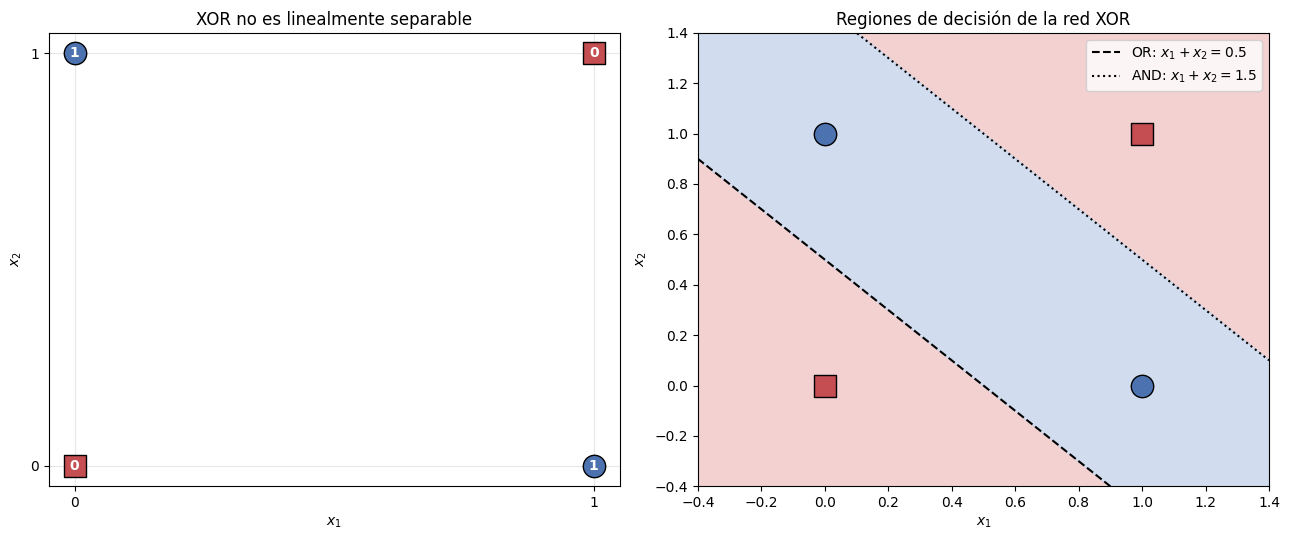

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# --- izquierda: XOR no separable ---
for (a, b), v in zip(entradas, xor_val):
    color = "#4C72B0" if v == 1 else "#C44E52"
    marca = "o" if v == 1 else "s"
    ax1.scatter(a, b, c=color, s=260, marker=marca, edgecolors="k", zorder=3)
    ax1.annotate(str(v), (a, b), ha="center", va="center",
                 color="white", fontweight="bold", zorder=4)
ax1.set_title("XOR no es linealmente separable")
ax1.set_xlabel("$x_1$"); ax1.set_ylabel("$x_2$")
ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1]); ax1.grid(alpha=0.3)

# --- derecha: regiones de decisión de la red ---
g = np.linspace(-0.4, 1.4, 300)
XX, YY = np.meshgrid(g, g)
Z = np.array([[xor_red(x, y)[0] for x, y in zip(fx, fy)] for fx, fy in zip(XX, YY)])
ax2.contourf(XX, YY, Z, levels=[-0.5, 0.5, 1.5],
             colors=["#f2c9c9", "#c9d6ec"], alpha=0.85)
xs = np.array([-0.4, 1.4])
ax2.plot(xs, 0.5 - xs, "k--", lw=1.5, label="OR: $x_1+x_2=0.5$")
ax2.plot(xs, 1.5 - xs, "k:",  lw=1.5, label="AND: $x_1+x_2=1.5$")
for (a, b), v in zip(entradas, xor_val):
    color = "#4C72B0" if v == 1 else "#C44E52"
    marca = "o" if v == 1 else "s"
    ax2.scatter(a, b, c=color, s=260, marker=marca, edgecolors="k", zorder=3)
ax2.set_xlim(-0.4, 1.4); ax2.set_ylim(-0.4, 1.4)
ax2.set_title("Regiones de decisión de la red XOR")
ax2.set_xlabel("$x_1$"); ax2.set_ylabel("$x_2$")
ax2.legend(loc="upper right")
plt.tight_layout(); plt.show()

## Conclusión

Un solo perceptrón no puede modelar XOR porque los puntos de cada clase están en diagonales opuestas y no hay recta que los separe. Conectando neuronas básicas —una capa oculta con OR y AND, y una neurona de salida que calcula "$h_1$ y no $h_2$"— sí se obtiene XOR, con estos pesos concretos:

| Neurona | entradas | pesos | sesgo | función |
|---|---|---|---|---|
| $h_1$ | $x_1, x_2$ | $[1,\,1]$ | $-0.5$ | OR |
| $h_2$ | $x_1, x_2$ | $[1,\,1]$ | $-1.5$ | AND |
| $y$ | $h_1, h_2$ | $[1,\,-1]$ | $-0.5$ | $h_1$ Y NO $h_2$ |

La idea general es que la capa oculta reexpresa las entradas en un espacio donde el problema ya es linealmente separable, y ahí la última neurona lo resuelve. Ese es el motivo por el que las redes de varias capas superan las limitaciones de un perceptrón solo.